# 01 — Data Understanding
**Project:** Insurance Fraud Detection Using Predictive Analytics and Machine Learning

This notebook covers Phase 2 of the project: dataset overview, shape, data types, missing values, duplicates, unique values, target distribution, and descriptive statistics.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import load_raw_data, basic_clean

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = load_raw_data('../data/raw/insurance_claims.csv')
df = basic_clean(df)
print("Shape:", df.shape)
df.head()

Shape: (1000, 39)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,NaN,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,NaN,0,0,NaN,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,NaN,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,NaN,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


## Dataset source and target variable

- **Source:** Auto Insurance Claims Fraud dataset (Kaggle-origin, mirrored on GitHub: `mwitiderrick/insurancedata`; documented on Mendeley by Aqqad, 2023).
- **Target:** `fraud_reported` — binary (`Y` = fraudulent claim, `N` = legitimate claim).
- **Observations:** 1,000 claims. **Features:** 39 raw columns.
- **Nature of data:** Widely understood to be a synthetically generated/anonymized teaching dataset, not real insurer records — absolute fraud rates and later dollar-impact figures should be read as illustrative, not representative of a real book of business.
- **PII check:** no names, addresses, or contact details. It does contain `age`, `insured_sex`, `insured_occupation`, `insured_hobbies`, `insured_zip` — quasi-identifiers relevant to the fairness discussion in notebook 07.

In [2]:
print("Data types:\n")
print(df.dtypes.value_counts())
print()
df.dtypes

Data types:

str        21
int64      17
float64     1
Name: count, dtype: int64



months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                   str
policy_state                       str
policy_csl                         str
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                        str
insured_education_level            str
insured_occupation                 str
insured_hobbies                    str
insured_relationship               str
capital-gains                    int64
capital-loss                     int64
incident_date                      str
incident_type                      str
collision_type                     str
incident_severity                  str
authorities_contacted              str
incident_state                     str
incident_city                      str
incident_location                  str
incident_hour_of_the_day 

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values (raw NaN + normalized '?' markers):")
missing

Columns with missing values (raw NaN + normalized '?' markers):


property_damage            360
police_report_available    343
collision_type             178
authorities_contacted       91
dtype: int64

**Observation:** `collision_type` (missing when the incident wasn't a collision, e.g. vehicle theft), `property_damage`, `police_report_available`, and `authorities_contacted` all carry missingness. This looks like **structural missingness** (the field legitimately doesn't apply, e.g. no collision type for a theft claim) rather than random data entry error — that will inform the imputation strategy in notebook 03 (most-frequent imputation is a pragmatic choice here, and we explicitly do not drop these rows, since missingness itself may correlate with claim type).

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Unique value counts per column (top 15 lowest-cardinality):")
df.nunique().sort_values().head(15)

Duplicate rows: 0

Unique value counts per column (top 15 lowest-cardinality):


insured_sex                    2
police_report_available        2
property_damage                2
fraud_reported                 2
bodily_injuries                3
collision_type                 3
policy_state                   3
policy_csl                     3
policy_deductable              3
incident_severity              4
incident_type                  4
authorities_contacted          4
witnesses                      4
number_of_vehicles_involved    4
insured_relationship           6
dtype: int64

fraud_reported
N    753
Y    247
Name: count, dtype: int64

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64


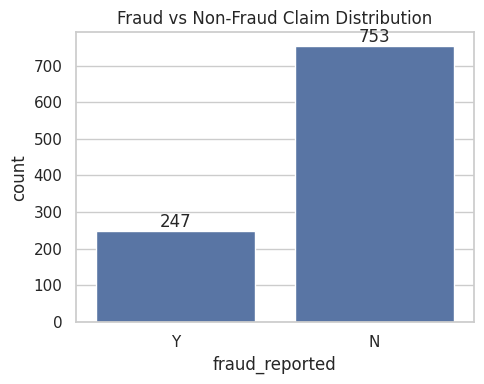

In [5]:
target_counts = df['fraud_reported'].value_counts()
target_pct = df['fraud_reported'].value_counts(normalize=True) * 100
print(target_counts)
print()
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='fraud_reported', data=df, ax=ax)
ax.set_title('Fraud vs Non-Fraud Claim Distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()

**Observation:** 247 of 1,000 claims (24.7%) are labeled fraudulent. This is a **moderate class imbalance** — not extreme (e.g. not 1-2% as in credit card fraud), but still imbalanced enough that accuracy alone would be a misleading metric (a model predicting "not fraud" for everything would already score 75.3% accuracy while catching zero fraud).

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):\n{numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")

Numeric columns (18):
['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

Categorical columns (21):
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


In [7]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


**Observation:** `umbrella_limit` has a minimum of -1,000,000, which is not a physically meaningful umbrella policy limit — this is a likely data-quality artifact/outlier that will need explicit handling in preprocessing (notebook 03) rather than being treated as a genuine signal.

In [8]:
for col in ['policy_state','insured_sex','insured_education_level','incident_type','incident_severity','authorities_contacted']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- policy_state ---
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

--- insured_sex ---
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64

--- insured_education_level ---
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64

--- incident_type ---
incident_type
Multi-vehicle Collision     419
Single Vehicle Collision    403
Vehicle Theft                94
Parked Car                   84
Name: count, dtype: int64

--- incident_severity ---
incident_severity
Minor Damage      354
Total Loss        280
Major Damage      276
Trivial Damage     90
Name: count, dtype: int64

--- authorities_contacted ---
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
NaN           91
Name: count, dtype: int64


## Summary of Phase 2 findings
- 1,000 claims, 39 features, binary target with 24.7% fraud rate (moderate imbalance).
- No exact duplicate rows.
- Missingness is structural (tied to incident type / whether an inquiry was made), concentrated in 4 categorical columns.
- `umbrella_limit` contains an implausible negative value that needs outlier handling.
- Both numeric (claim amounts, tenure, premium) and categorical (incident type/severity, demographics, policy characteristics) features are present — supports a broad EDA in notebook 02.